<a href="https://colab.research.google.com/github/SuntsovaMaria/ML/blob/main/Homework7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
# Импорт необходимых библиотек
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [3]:
url = 'https://drive.google.com/uc?id=1ut284Z8aYM-CIbZj9nZLAZKYPOkP43dr'
df = pd.read_csv(url, encoding='utf-8')
print(f"Столбцы: {list(df.columns)}")

Столбцы: ['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title', 'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money', 'Recommended']


In [20]:
rating_cols = [
    'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
    'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity',
    'Value For Money', 'Overall_Rating'
]


categorical_cols = [
    'Airline Name', 'Type Of Traveller', 'Seat Type', 'Verified'
]

print("Числовые признаки (оценки):")
for col in rating_cols:
    print(f"  - {col}")


print("\nКатегориальные признаки:")
for col in categorical_cols:
    print(f"  - {col}")
cat_cols_to_encode = ['Type Of Traveller', 'Seat Type','Verfied']
for col in cat_cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()

        df[col] = df[col].fillna('Unknown')
        categorical_features[col] = le.fit_transform(df[col])
categorical_features= pd.DataFrame()
for col in cat_cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()


        if 'Missing' in df[col].values:

            pass

        mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'

        df[col] = df[col].fillna(mode_value)

        categorical_features[col] = le.fit_transform(df[col])

# Обрабатываем Overall_Rating (удаляем 'n')
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')
#обработка пропущенных значений
imputer = SimpleImputer(strategy='median')
df[rating_cols] = imputer.fit_transform(df[rating_cols])



Числовые признаки (оценки):
  - Seat Comfort
  - Cabin Staff Service
  - Food & Beverages
  - Ground Service
  - Inflight Entertainment
  - Wifi & Connectivity
  - Value For Money
  - Overall_Rating

Категориальные признаки:
  - Airline Name
  - Type Of Traveller
  - Seat Type
  - Verified


In [21]:
text_data = df['Review_Title'].fillna('') + ' ' + df['Review'].fillna('')

# TF-IDF векторизация
tfidf = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    min_df=500,
    max_df=0.7
)

text_features = tfidf.fit_transform(text_data)
feature_names = tfidf.get_feature_names_out()
print(f"   Создано {text_features.shape[1]} текстовых признаков")
print("Слова после TF-IDF векторизации:")
print(feature_names)

# Уменьшаем размерность текстовых признаков для ускорения работы
svd = TruncatedSVD(n_components=10, random_state=42)
text_features_reduced = svd.fit_transform(text_features)
text_df = pd.DataFrame(text_features_reduced,
                       columns=[f'text_svd_{i}' for i in range(10)])


   Создано 100 текстовых признаков
Слова после TF-IDF векторизации:
['10' '30' 'air' 'aircraft' 'airline' 'airlines' 'airport' 'airways'
 'arrived' 'asked' 'bad' 'bag' 'baggage' 'bags' 'board' 'boarding'
 'booked' 'business' 'cabin' 'cancelled' 'change' 'check' 'checked'
 'class' 'comfortable' 'company' 'cost' 'crew' 'customer' 'day' 'days'
 'delay' 'delayed' 'departure' 'did' 'didn' 'don' 'drinks' 'economy'
 'entertainment' 'experience' 'extra' 'flew' 'flights' 'fly' 'flying'
 'food' 'friendly' 'gate' 'good' 'got' 'great' 'help' 'hour' 'hours'
 'just' 'late' 'later' 'left' 'like' 'long' 'luggage' 'make' 'meal'
 'minutes' 'money' 'new' 'nice' 'offered' 'old' 'paid' 'passengers' 'pay'
 'people' 'plane' 'really' 'recommend' 'refund' 'return' 'review' 'said'
 'seat' 'seats' 'service' 'staff' 'ticket' 'tickets' 'time' 'times' 'told'
 'took' 'travel' 'trip' 'use' 'wait' 'waiting' 'water' 'way' 'went'
 'worst']


In [25]:
final_features = pd.concat([
    df[rating_cols].reset_index(drop=True),
    categorical_features.reset_index(drop=True),
    text_df.reset_index(drop=True)
], axis=1)
scaler=StandardScaler()
final_features_scaled = scaler.fit_transform(final_features)
print(f"Итоговый размер признакового пространства: {final_features.shape}")


Итоговый размер признакового пространства: (23171, 20)


Оптимальное количество кластеров (по силуэту): 2


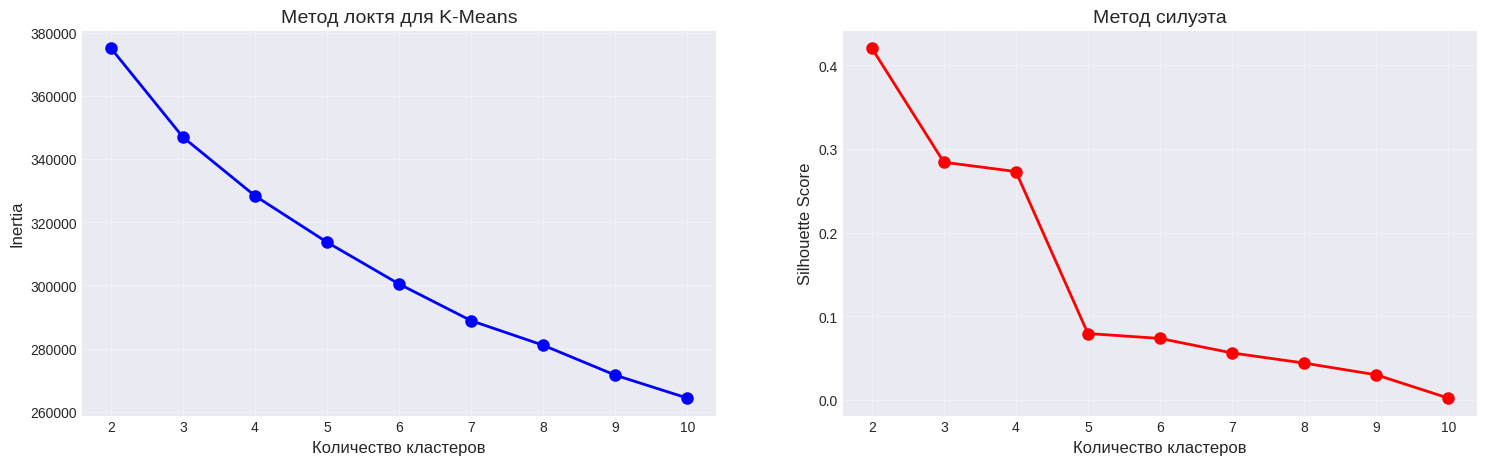

In [27]:
# Метод локтя для K-Means
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(final_features_scaled)
    inertia.append(kmeans.inertia_)

    if len(set(kmeans.labels_)) > 1:
        silhouette_scores.append(silhouette_score(final_features, kmeans.labels_))
    else:
        silhouette_scores.append(0)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# График метода локтя
axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Метод локтя для K-Means', fontsize=14)
axes[0].grid(True, alpha=0.3)

# График силуэтного коэффициента
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Метод силуэта', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Определяем оптимальное количество кластеров
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров (по силуэту): {optimal_k}")

In [33]:
print("1. Применение K-Means...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(final_features_scaled)
df['kmeans_cluster'] = kmeans_labels

print("2. Применение DBSCAN...")
dbscan = DBSCAN(eps=1.5, min_samples=20)
dbscan_labels = dbscan.fit_predict(final_features_scaled)
df['dbscan_cluster'] = dbscan_labels

print("3. Применение Agglomerative Clustering...")
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(final_features_scaled)
df['agglo_cluster'] = agglo_labels

1. Применение K-Means...
2. Применение DBSCAN...
3. Применение Agglomerative Clustering...


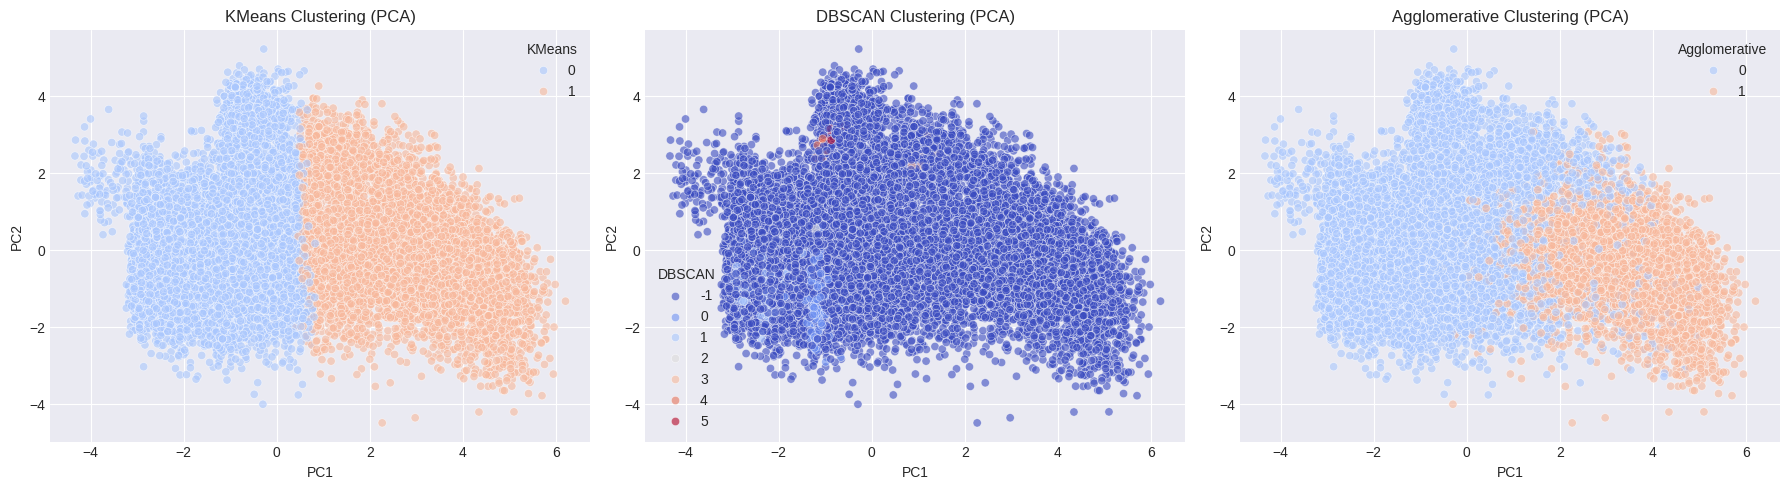

In [44]:
pca = PCA(n_components=2, random_state=42)
value_pca = pca.fit_transform(final_features_scaled)

viz_df = pd.DataFrame(value_pca, columns=['PC1', 'PC2'])
viz_df['KMeans'] = kmeans_labels
viz_df['DBSCAN'] = dbscan_labels
viz_df['Agglomerative'] = agglo_labels

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clusters = ['KMeans', 'DBSCAN', 'Agglomerative']
titles = ['KMeans Clustering', 'DBSCAN Clustering', 'Agglomerative Clustering']
palettes = ['coolwarm','coolwarm','coolwarm']

for ax, method, title, palette in zip(axes, clusters, titles, palettes):
    sns.scatterplot(
        data=viz_df,
        x='PC1',
        y='PC2',
        hue=method,
        palette=palette,
        ax=ax,
        legend='full',
        alpha=0.6
    )
    ax.set_title(f'{title} (PCA)')

plt.tight_layout()
plt.show()

In [35]:
def evaluate_clustering(true_labels, pred_labels, method_name):
    print(f"\n--- Оценка для {method_name} ---")

    # Метрики качества
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    h_score = homogeneity_score(true_labels, pred_labels)
    c_score = completeness_score(true_labels, pred_labels)
    v_score = v_measure_score(true_labels, pred_labels)

    print(f"  ARI: {ari:.3f}")
    print(f"  NMI: {nmi:.3f}")
    print(f"  Homogeneity: {h_score:.3f}")
    print(f"  Completeness: {c_score:.3f}")
    print(f"  V-measure: {v_score:.3f}")

    # Информация о кластерах
    unique_pred = set(pred_labels)
    n_clusters = len(unique_pred) - (1 if -1 in unique_pred else 0)
    print(f"  Количество кластеров: {n_clusters}")

    if -1 in unique_pred:
        n_noise = sum(pred_labels == -1)
        print(f"  Меток шума (-1): {n_noise} ({n_noise/len(pred_labels)*100:.1f}%)")

    # Silhouette score (если больше 1 кластера и нет шума)
    if len(unique_pred) > 1 and -1 not in unique_pred:
        sil_score = silhouette_score(final_features_scaled[:len(pred_labels)], pred_labels)
        print(f"  Silhouette Score: {sil_score:.3f}")

    # Таблица сопряженности
    crosstab = pd.crosstab(pd.Series(pred_labels, name='Cluster'),
                          pd.Series(true_labels, name='True_Label'))
    print(f"\n  Таблица сопряженности:")
    print(crosstab)


# Проверка данных и выполнение оценки
true_labels = df['Recommended'].values if 'Recommended' in df.columns else None

clustering_methods = {
    'kmeans_labels': kmeans_labels if 'kmeans_labels' in globals() else None,
    'labels_dbscan': dbscan_labels if 'labels_dbscan' in globals() else None,
    'agglo_labels': agglo_labels if 'agglo_labels' in globals() else None
}

print("ВЫПОЛНЕНИЕ ОЦЕНКИ КЛАСТЕРИЗАЦИИ")
print("="*50)

if true_labels is not None:
    for method_name, pred_labels in clustering_methods.items():
        if pred_labels is not None:
            evaluate_clustering(true_labels, pred_labels, method_name)
else:
    print("Не найден столбец 'Recommended' для оценки")

ВЫПОЛНЕНИЕ ОЦЕНКИ КЛАСТЕРИЗАЦИИ

--- Оценка для kmeans_labels ---
  ARI: 0.748
  NMI: 0.624
  Homogeneity: 0.626
  Completeness: 0.622
  V-measure: 0.624
  Количество кластеров: 2
  Silhouette Score: 0.204

  Таблица сопряженности:
True_Label     no   yes
Cluster                
0           14520   701
1             844  7106

--- Оценка для labels_dbscan ---
  ARI: -0.053
  NMI: 0.064
  Homogeneity: 0.049
  Completeness: 0.093
  V-measure: 0.064
  Количество кластеров: 6
  Меток шума (-1): 21402 (92.4%)

  Таблица сопряженности:
True_Label     no   yes
Cluster                
-1          13625  7777
 0            989     7
 1            698     2
 2             15     0
 3              0    21
 4             20     0
 5             17     0

--- Оценка для agglo_labels ---
  ARI: 0.547
  NMI: 0.451
  Homogeneity: 0.420
  Completeness: 0.488
  V-measure: 0.451
  Количество кластеров: 2
  Silhouette Score: 0.198

  Таблица сопряженности:
True_Label     no   yes
Cluster                
0

**Выводы:** k-means показал приемлимый результат, причем кластеры достаточно хорошо согласуются с истинными метками (0-no,1-yes),но если в истинных метках доля yes~33%, то здесь кластер 1 ~ 30%. DBScan справился плохо большую часть данных определил как шум, остальные данные разделил по кластерам. Agglomerative clusterring показал себя немного хуже чем K-means, но тоже способен справиться с задачей. На графиках видно, что граница K-means менее размыта и почти идет по прямой.